# MDR-TS v22.2
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v22.2
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

- Reviewing and implementing the feedback from Dr. Zhou

## Imports

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import xgboost as xgb

import torch
import pickle

models_root = os.path.abspath("../../")
if models_root not in sys.path:
    sys.path.insert(0, models_root)

from Temporal.Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

# boundary thresholds for regimes
t1 = 0.20
t2 = 0.313

imports loaded
using: cpu


In [2]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


In [3]:
VERSION = "v22"
SUBVERSION = "v22.2"
RUN_NAME = "mdr_ts_v22_2"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v22/v22.2

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/test.csv


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 499

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


## Features

In [6]:
TARGET_COL = "soil_moisture_5cm"
KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

### Transition

In [7]:
FEATURE_COLS_TRANSITION = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_ampm_diff_interp",

    "SMAP_sm_interp_lag1",
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollmean7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "V_ema_G_API_kobs7",
    "V_ema_G_API_kobs14",
    "V_ema_G_API_kobs30",
    "V_rollmean_G_API_kobs7",
    "V_rollmean_G_API_kobs14",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs14",
    "V_ema_LST_modis_kobs7",
    "A_d_LST_modis_kobs14",
    "V_rollmin_LST_modis_kobs30",
    "V_rollmean_s2_b11_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "API_x_year", "SMAP_x_year",
    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",
]

### Dry

In [8]:
FEATURE_COLS_DRY = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_sm_interp_diff1",
    "A_d_SMAP_sm_interp_kobs14",

    "V_ema_LST_modis_kobs7",
    "V_rollmin_LST_modis_kobs30",
    "A_d_LST_modis_kobs14",

    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",

    "G_API",
    "V_ema_G_API_kobs14",
    "C_lag_G_API_kobs1",

    "G_DSLR",

    "V_rollmean_s2_b11_kobs7",
    "year_frac", "sin_year", "cos_year",
]


### Wet

In [9]:
FEATURE_COLS_WET = [
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollstd7",
    "SMAP_sm_interp_rollrange7",
    "SMAP_sm_interp_pctchg",
    "A_d_SMAP_sm_interp_kobs7",
    "A_grad_SMAP_sm_interp_kobs7",
    "A_pct_SMAP_sm_interp",

    "SMAP_sm_interp_lag7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",

    "G_rain_sum_30d",

    "V_rollstd_G_API_kobs7",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs1",
    "A_d_E_SAR_diff_kobs7",
    "A_grad_E_SAR_diff_kobs7",
    "A_grad_E_SAR_ratio_kobs7",
    "V_rollstd_E_SAR_diff_kobs7",
    "V_rollstd_E_SAR_ratio_kobs7",

    "V_rollstd_F_NDMI_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "slope", "elev",
]

### New: Transition

In [10]:
train_df["tr_api_x_lst"] = train_df["G_API"] * train_df["LST_modis"]
val_df["tr_api_x_lst"]   = val_df["G_API"] * val_df["LST_modis"]
test_df["tr_api_x_lst"]  = test_df["G_API"] * test_df["LST_modis"]

train_df["tr_api_x_slope"] = train_df["G_API"] * train_df["slope"]
val_df["tr_api_x_slope"]   = val_df["G_API"] * val_df["slope"]
test_df["tr_api_x_slope"]  = test_df["G_API"] * test_df["slope"]

train_df["tr_smap_x_season"] = train_df["SMAP_sm_interp"] * train_df["sin_year"]
val_df["tr_smap_x_season"]   = val_df["SMAP_sm_interp"] * val_df["sin_year"]
test_df["tr_smap_x_season"]  = test_df["SMAP_sm_interp"] * test_df["sin_year"]

FEATURE_COLS_TRANSITION += [
    "tr_api_x_lst",
    "tr_api_x_slope",
    "tr_smap_x_season"
]

In [11]:
def _check_cols(df, cols, name):
    missing = sorted(set(cols) - set(df.columns))
    if missing:
        raise ValueError(f"Missing columns in {name}: {missing}")

for _df_name, _df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    _check_cols(_df, KEEP_META_COLS + [TARGET_COL], _df_name)
    _check_cols(_df, FEATURE_COLS_TRANSITION, f"{_df_name} (TRANSITION)")
    _check_cols(_df, FEATURE_COLS_DRY, f"{_df_name} (DRY)")
    _check_cols(_df, FEATURE_COLS_WET, f"{_df_name} (WET)")

print("Columns locked")
print("  TRANSITION features:", len(FEATURE_COLS_TRANSITION))
print("  DRY        features:", len(FEATURE_COLS_DRY))
print("  WET        features:", len(FEATURE_COLS_WET))
print("  Target:", TARGET_COL)

Columns locked
  TRANSITION features: 37
  DRY        features: 22
  WET        features: 28
  Target: soil_moisture_5cm


## Utils

In [12]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics, title=None, decimals=5):
    preferred_order = [
        "n", "r2", "mae", "rmse", "ubrmse", "bias",
        "med_ae", "p90_ae",
        "q05_err", "q50_err", "q95_err",
    ]

    keys = list(metrics.keys())
    if "_" in keys[0]:
        prefix = keys[0].split("_")[0] + "_"
    else:
        prefix = ""

    ordered_keys = []
    for k in preferred_order:
        full_key = prefix + k
        if full_key in metrics:
            ordered_keys.append(full_key)

    for k in metrics:
        if k not in ordered_keys:
            ordered_keys.append(k)

    if title:
        print(f"\n{title}")
    print("=" * 42)
    print(f"{'Metric':<18} {'Value':>18}")
    print("-" * 42)

    for k in ordered_keys:
        v = metrics[k]

        if isinstance(v, int):
            val_str = f"{v:,}"
        else:
            val_str = f"{v:.{decimals}f}"

        print(f"{k:<18} {val_str:>18}")

    print("=" * 42)

def get_xgb_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    s = imp.sum()
    if s > 0:
        imp = imp / s
    return imp

TOP_K = 15

def plot_top_features(model, feature_cols, title):
    imp = get_xgb_importance(model, feature_cols)
    imp_top = imp.sort_values(ascending=False).head(TOP_K)

    print(f"\n{title} - Top {TOP_K} Features")
    print("=" * 50)
    print(imp_top.to_string())

    plt.figure(figsize=(6, max(4, 0.4 * TOP_K)))
    y = np.arange(len(imp_top))

    plt.barh(y, imp_top.values)
    plt.yticks(y, imp_top.index)
    plt.gca().invert_yaxis()

    plt.title(title)
    plt.xlabel("Normalized importance")
    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_residuals(y_true, y_pred, title):
    res = y_pred - y_true

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].scatter(y_pred, res, s=8, alpha=0.4)
    axes[0].axhline(0, linestyle='--')
    axes[0].set_title(f"{title} | Residual vs Pred")
    axes[0].set_xlabel("Prediction")
    axes[0].set_ylabel("Residual")

    axes[1].hist(res, bins=50)
    axes[1].set_title(f"{title} | Residual Distribution")

    axes[2].scatter(y_true, res, s=8, alpha=0.4)
    axes[2].axhline(0, linestyle='--')
    axes[2].set_title(f"{title} | Residual vs True")
    axes[2].set_xlabel("True")
    axes[2].set_ylabel("Residual")

    plt.tight_layout()
    plt.show()

    print(f"{title} mean residual (bias): {res.mean():.6f}")
    print(f"{title} median residual: {np.median(res):.6f}")

def residual_by_bins(y_true, y_pred, title, n_bins=10):
    res = y_pred - y_true
    bins = np.linspace(y_true.min(), y_true.max(), n_bins + 1)

    print(f"\n{title} | Residual by true-value bins")

    for i in range(n_bins):
        mask = (y_true >= bins[i]) & (y_true < bins[i+1])
        if mask.sum() == 0:
            continue
        print(
            f"bin {i}: "
            f"y in [{bins[i]:.3f}, {bins[i+1]:.3f}] | "
            f"mean res = {res[mask].mean():.5f} | n={mask.sum()}"
        )

### Split

In [13]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     6868
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2017-01-01 -- 2020-12-31

VAL
  rows:     2720
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-01-01 -- 2022-12-31

TEST
  rows:     4016
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-01 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [14]:
y_train = train_df[TARGET_COL].copy()
y_val = val_df[TARGET_COL].copy()
y_test = test_df[TARGET_COL].copy()

trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
y_trainval = trainval_df[TARGET_COL].copy()

X_train_dry = train_df[FEATURE_COLS_DRY].copy()
X_val_dry = val_df[FEATURE_COLS_DRY].copy()
X_test_dry = test_df[FEATURE_COLS_DRY].copy()
X_trainval_dry = trainval_df[FEATURE_COLS_DRY].copy()

X_train_transition = train_df[FEATURE_COLS_TRANSITION].copy()
X_val_transition = val_df[FEATURE_COLS_TRANSITION].copy()
X_test_transition = test_df[FEATURE_COLS_TRANSITION].copy()
X_trainval_transition = trainval_df[FEATURE_COLS_TRANSITION].copy()

X_train_wet = train_df[FEATURE_COLS_WET].copy()
X_val_wet = val_df[FEATURE_COLS_WET].copy()
X_test_wet = test_df[FEATURE_COLS_WET].copy()
X_trainval_wet = trainval_df[FEATURE_COLS_WET].copy()

print("\nBase matrix shapes:")
print("  DRY        train:", X_train_dry.shape,        "val:", X_val_dry.shape,        "test:", X_test_dry.shape)
print("  TRANSITION train:", X_train_transition.shape, "val:", X_val_transition.shape, "test:", X_test_transition.shape)
print("  WET        train:", X_train_wet.shape,        "val:", X_val_wet.shape,        "test:", X_test_wet.shape)

print("\nTrain+Val shapes:")
print("  y_trainval:", y_trainval.shape)
print("  DRY        trainval:", X_trainval_dry.shape)
print("  TRANSITION trainval:", X_trainval_transition.shape)
print("  WET        trainval:", X_trainval_wet.shape)


Base matrix shapes:
  DRY        train: (6868, 22) val: (2720, 22) test: (4016, 22)
  TRANSITION train: (6868, 37) val: (2720, 37) test: (4016, 37)
  WET        train: (6868, 28) val: (2720, 28) test: (4016, 28)

Train+Val shapes:
  y_trainval: (9588,)
  DRY        trainval: (9588, 22)
  TRANSITION trainval: (9588, 37)
  WET        trainval: (9588, 28)


In [15]:
POSITION_BASE_COL = "SMAP_sm_interp_lag1"
T1 = 0.20
T2 = 0.313
MIDPOINT = (T1 + T2) / 2.0

for _df_name, _df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df),
    ("trainval", trainval_df),
]:
    if POSITION_BASE_COL not in _df.columns:
        raise ValueError(f"{POSITION_BASE_COL} missing in {_df_name}")

POSITION_FEATURES = [
    f"{POSITION_BASE_COL}_pos_raw",
    f"{POSITION_BASE_COL}_dist_t1",
    f"{POSITION_BASE_COL}_dist_t2",
    f"{POSITION_BASE_COL}_centered",
    f"{POSITION_BASE_COL}_sq",
    f"{POSITION_BASE_COL}_centered_sq",
    f"{POSITION_BASE_COL}_span_norm",
]

def add_position_features(X, source_df, base_col=POSITION_BASE_COL, t1=T1, t2=T2):
    X = X.copy()

    base = source_df.loc[X.index, base_col].astype(float)
    mid = (t1 + t2) / 2.0
    span = t2 - t1

    X[f"{base_col}_pos_raw"] = base
    X[f"{base_col}_dist_t1"] = base - t1
    X[f"{base_col}_dist_t2"] = base - t2
    X[f"{base_col}_centered"] = base - mid
    X[f"{base_col}_sq"] = base ** 2
    X[f"{base_col}_centered_sq"] = (base - mid) ** 2
    X[f"{base_col}_span_norm"] = (base - t1) / span

    return X

In [16]:
X_train_transition = add_position_features(X_train_transition, train_df)
X_val_transition = add_position_features(X_val_transition, val_df)
X_test_transition = add_position_features(X_test_transition, test_df)
X_trainval_transition = add_position_features(X_trainval_transition, trainval_df)

# add to wet matrices
X_train_wet = add_position_features(X_train_wet, train_df)
X_val_wet = add_position_features(X_val_wet, val_df)
X_test_wet = add_position_features(X_test_wet, test_df)
X_trainval_wet = add_position_features(X_trainval_wet, trainval_df)

FEATURE_COLS_TRANSITION_FINAL = list(X_train_transition.columns)
FEATURE_COLS_WET_FINAL = list(X_train_wet.columns)

print("\nAdded engineered features using:", POSITION_BASE_COL)
print("  TRANSITION train:", X_train_transition.shape, "val:", X_val_transition.shape, "test:", X_test_transition.shape)
print("  WET        train:", X_train_wet.shape, "val:", X_val_wet.shape, "test:", X_test_wet.shape)

print("\nEngineered transition/wet features:")
print(POSITION_FEATURES)


Added engineered features using: SMAP_sm_interp_lag1
  TRANSITION train: (6868, 44) val: (2720, 44) test: (4016, 44)
  WET        train: (6868, 35) val: (2720, 35) test: (4016, 35)

Engineered transition/wet features:
['SMAP_sm_interp_lag1_pos_raw', 'SMAP_sm_interp_lag1_dist_t1', 'SMAP_sm_interp_lag1_dist_t2', 'SMAP_sm_interp_lag1_centered', 'SMAP_sm_interp_lag1_sq', 'SMAP_sm_interp_lag1_centered_sq', 'SMAP_sm_interp_lag1_span_norm']


### Inner Split

In [17]:
# ============================================================
# Hard regime assignment
# 0 = dry
# 1 = transition_low
# 2 = transition_high
# 3 = wet
# ============================================================

t1 = T1
t2 = T2
mid = MIDPOINT

def assign_regime(y, t1=t1, t2=t2, mid=mid):
    y_arr = np.asarray(y).ravel()
    reg = np.zeros_like(y_arr, dtype=int)

    reg[y_arr <= t1] = 0
    reg[(y_arr > t1) & (y_arr <= mid)] = 1
    reg[(y_arr > mid) & (y_arr <= t2)] = 2
    reg[y_arr > t2] = 3

    return reg

reg_train = assign_regime(y_train)
reg_val   = assign_regime(y_val)
reg_test  = assign_regime(y_test)
reg_trainval = assign_regime(y_trainval)

mask_train_dry = reg_train == 0
mask_train_trans_low = reg_train == 1
mask_train_trans_high = reg_train == 2
mask_train_wet = reg_train == 3

mask_val_dry = reg_val == 0
mask_val_trans_low = reg_val == 1
mask_val_trans_high = reg_val == 2
mask_val_wet = reg_val == 3

mask_test_dry = reg_test == 0
mask_test_trans_low = reg_test == 1
mask_test_trans_high = reg_test == 2
mask_test_wet = reg_test == 3

mask_trainval_dry = reg_trainval == 0
mask_trainval_trans_low = reg_trainval == 1
mask_trainval_trans_high = reg_trainval == 2
mask_trainval_wet = reg_trainval == 3

y_train_dry = y_train.loc[mask_train_dry].copy()
y_train_trans_low = y_train.loc[mask_train_trans_low].copy()
y_train_trans_high = y_train.loc[mask_train_trans_high].copy()
y_train_wet = y_train.loc[mask_train_wet].copy()

y_val_dry = y_val.loc[mask_val_dry].copy()
y_val_trans_low = y_val.loc[mask_val_trans_low].copy()
y_val_trans_high = y_val.loc[mask_val_trans_high].copy()
y_val_wet = y_val.loc[mask_val_wet].copy()

y_test_dry = y_test.loc[mask_test_dry].copy()
y_test_trans_low = y_test.loc[mask_test_trans_low].copy()
y_test_trans_high = y_test.loc[mask_test_trans_high].copy()
y_test_wet = y_test.loc[mask_test_wet].copy()

y_trainval_dry = y_trainval.loc[mask_trainval_dry].copy()
y_trainval_trans_low = y_trainval.loc[mask_trainval_trans_low].copy()
y_trainval_trans_high = y_trainval.loc[mask_trainval_trans_high].copy()
y_trainval_wet = y_trainval.loc[mask_trainval_wet].copy()

X_train_dry_regime = X_train_dry.loc[mask_train_dry].copy()
X_val_dry_regime = X_val_dry.loc[mask_val_dry].copy()
X_test_dry_regime = X_test_dry.loc[mask_test_dry].copy()
X_trainval_dry_regime = X_trainval_dry.loc[mask_trainval_dry].copy()

X_train_trans_low = X_train_transition.loc[mask_train_trans_low].copy()
X_val_trans_low = X_val_transition.loc[mask_val_trans_low].copy()
X_test_trans_low = X_test_transition.loc[mask_test_trans_low].copy()
X_trainval_trans_low = X_trainval_transition.loc[mask_trainval_trans_low].copy()

X_train_trans_high = X_train_transition.loc[mask_train_trans_high].copy()
X_val_trans_high = X_val_transition.loc[mask_val_trans_high].copy()
X_test_trans_high = X_test_transition.loc[mask_test_trans_high].copy()
X_trainval_trans_high = X_trainval_transition.loc[mask_trainval_trans_high].copy()

X_train_wet_regime = X_train_wet.loc[mask_train_wet].copy()
X_val_wet_regime = X_val_wet.loc[mask_val_wet].copy()
X_test_wet_regime = X_test_wet.loc[mask_test_wet].copy()
X_trainval_wet_regime = X_trainval_wet.loc[mask_trainval_wet].copy()

print(f"Thresholds: t1={t1:.3f}, mid={mid:.3f}, t2={t2:.3f}")

print("\nTrain regime counts:", {
    "dry": int(mask_train_dry.sum()),
    "trans_low": int(mask_train_trans_low.sum()),
    "trans_high": int(mask_train_trans_high.sum()),
    "wet": int(mask_train_wet.sum()),
})

print("Val regime counts:", {
    "dry": int(mask_val_dry.sum()),
    "trans_low": int(mask_val_trans_low.sum()),
    "trans_high": int(mask_val_trans_high.sum()),
    "wet": int(mask_val_wet.sum()),
})

print("Test regime counts:", {
    "dry": int(mask_test_dry.sum()),
    "trans_low": int(mask_test_trans_low.sum()),
    "trans_high": int(mask_test_trans_high.sum()),
    "wet": int(mask_test_wet.sum()),
})

print("\nRegime matrix shapes:")
print("  DRY        train:", X_train_dry_regime.shape,      "val:", X_val_dry_regime.shape,      "test:", X_test_dry_regime.shape)
print("  TRANS LOW  train:", X_train_trans_low.shape,       "val:", X_val_trans_low.shape,       "test:", X_test_trans_low.shape)
print("  TRANS HIGH train:", X_train_trans_high.shape,      "val:", X_val_trans_high.shape,      "test:", X_test_trans_high.shape)
print("  WET        train:", X_train_wet_regime.shape,      "val:", X_val_wet_regime.shape,      "test:", X_test_wet_regime.shape)

Thresholds: t1=0.200, mid=0.257, t2=0.313

Train regime counts: {'dry': 3292, 'trans_low': 1317, 'trans_high': 1412, 'wet': 847}
Val regime counts: {'dry': 988, 'trans_low': 360, 'trans_high': 796, 'wet': 576}
Test regime counts: {'dry': 1509, 'trans_low': 850, 'trans_high': 1165, 'wet': 492}

Regime matrix shapes:
  DRY        train: (3292, 22) val: (988, 22) test: (1509, 22)
  TRANS LOW  train: (1317, 44) val: (360, 44) test: (850, 44)
  TRANS HIGH train: (1412, 44) val: (796, 44) test: (1165, 44)
  WET        train: (847, 35) val: (576, 35) test: (492, 35)


### Dry Model

In [18]:
XGB_PARAMS_DRY = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

X_train_dry_regime = X_train_dry.loc[mask_train_dry].copy()
X_val_dry_regime   = X_val_dry.loc[mask_val_dry].copy()
X_test_dry_regime  = X_test_dry.loc[mask_test_dry].copy()

y_train_dry = y_train.loc[mask_train_dry].copy()
y_val_dry   = y_val.loc[mask_val_dry].copy()
y_test_dry  = y_test.loc[mask_test_dry].copy()

dry_model = xgb.XGBRegressor(**XGB_PARAMS_DRY)

dry_model.fit(
    X_train_dry_regime,
    y_train_dry,
    eval_set=[(X_val_dry_regime, y_val_dry)],
    verbose=False,
)

pred_dry_train = dry_model.predict(X_train_dry_regime)
pred_dry_val   = dry_model.predict(X_val_dry_regime)
pred_dry_test  = dry_model.predict(X_test_dry_regime)

print("Dry expert trained")
print("  train:", X_train_dry_regime.shape)
print("  val:  ", X_val_dry_regime.shape)
print("  test: ", X_test_dry_regime.shape)

Dry expert trained
  train: (3292, 22)
  val:   (988, 22)
  test:  (1509, 22)



Dry Model - Top 15 Features
J_sand_wfrac_b0               0.119004
K_aspect_cos                  0.075873
K_slope_sin                   0.075119
J_clay_wfrac_b0               0.071434
K_slope_cos                   0.064977
year_frac                     0.045116
slope                         0.042929
V_rollmin_LST_modis_kobs30    0.042810
sin_year                      0.040940
cos_year                      0.039811
SMAP_sm_interp_diff1          0.038442
V_ema_G_API_kobs14            0.038214
elev                          0.035516
C_lag_G_API_kobs1             0.035270
A_d_LST_modis_kobs14          0.033618


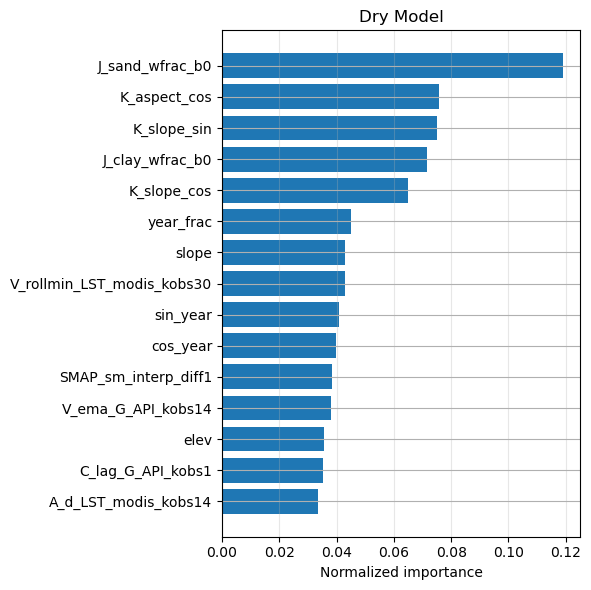

In [19]:
plot_top_features(dry_model, FEATURE_COLS_DRY, "Dry Model")

### Wet Model

In [20]:
XGB_PARAMS_WET = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=6,
    min_child_weight=4,
    subsample=0.9,
    colsample_bytree=0.85,
    n_estimators=3500,
    learning_rate=0.025,
    reg_lambda=2.0,
    reg_alpha=0.02,
    gamma=0.0,
)

X_train_wet_regime = X_train_wet.loc[mask_train_wet].copy()
X_val_wet_regime   = X_val_wet.loc[mask_val_wet].copy()
X_test_wet_regime  = X_test_wet.loc[mask_test_wet].copy()

y_train_wet = y_train.loc[mask_train_wet].copy()
y_val_wet   = y_val.loc[mask_val_wet].copy()
y_test_wet  = y_test.loc[mask_test_wet].copy()

wet_model = xgb.XGBRegressor(**XGB_PARAMS_WET)

wet_model.fit(
    X_train_wet_regime,
    y_train_wet,
    eval_set=[(X_val_wet_regime, y_val_wet)],
    verbose=False,
)

pred_wet_train = wet_model.predict(X_train_wet_regime)
pred_wet_val   = wet_model.predict(X_val_wet_regime)
pred_wet_test  = wet_model.predict(X_test_wet_regime)

print("Wet expert trained (direct)")

Wet expert trained (direct)



Wet Model - Top 15 Features
elev                               0.252764
slope                              0.129246
year_frac                          0.089078
SMAP_sm_interp_lag1_dist_t2        0.071359
V_rollstd_E_SAR_diff_kobs7         0.047210
SMAP_sm_interp_rollrange7          0.044178
SMAP_sm_interp_lag1_centered       0.038031
A_d_E_SAR_diff_kobs7               0.029901
A_d_SMAP_sm_interp_kobs7           0.028360
A_grad_SMAP_sm_interp_kobs7        0.025330
cos_year                           0.021568
SMAP_sm_interp_lag1_pos_raw        0.021466
G_rain_sum_7d                      0.020377
SMAP_sm_interp_lag1_centered_sq    0.018499
SMAP_sm_interp_lag7                0.018275


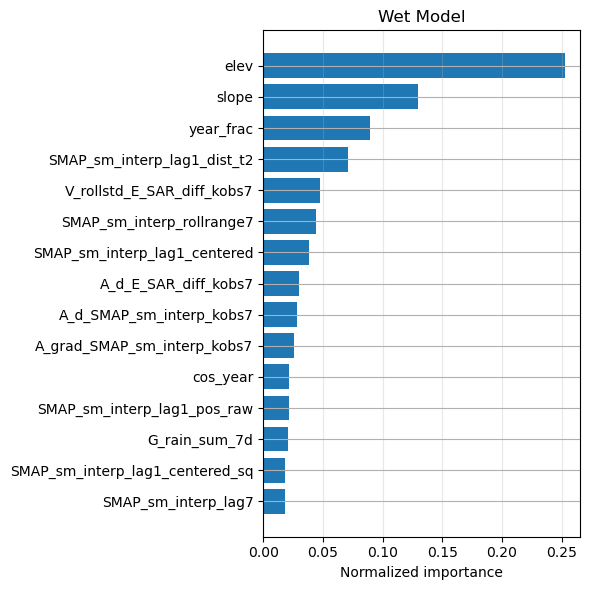

In [21]:
plot_top_features(wet_model, FEATURE_COLS_WET_FINAL, "Wet Model")

### Transition Model

In [22]:
XGB_PARAMS_TRANS_LOW = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=6,
    min_child_weight=4,
    subsample=0.9,
    colsample_bytree=0.85,
    n_estimators=4000,
    learning_rate=0.025,
    reg_lambda=2.0,
    reg_alpha=0.02,
    gamma=0.0,
)

trans_low_model = xgb.XGBRegressor(**XGB_PARAMS_TRANS_LOW)

trans_low_model.fit(
    X_train_trans_low,
    y_train_trans_low,
    eval_set=[(X_val_trans_low, y_val_trans_low)],
    verbose=False,
)

pred_trans_low_train = trans_low_model.predict(X_train_trans_low)
pred_trans_low_val   = trans_low_model.predict(X_val_trans_low)
pred_trans_low_test  = trans_low_model.predict(X_test_trans_low)

print("Transition-low expert trained")
print("  train:", X_train_trans_low.shape)
print("  val:  ", X_val_trans_low.shape)
print("  test: ", X_test_trans_low.shape)

XGB_PARAMS_TRANS_HIGH = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=7,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.85,
    n_estimators=5000,
    learning_rate=0.022,
    reg_lambda=2.0,
    reg_alpha=0.02,
    gamma=0.0,
)

trans_high_model = xgb.XGBRegressor(**XGB_PARAMS_TRANS_HIGH)

trans_high_model.fit(
    X_train_trans_high,
    y_train_trans_high,
    eval_set=[(X_val_trans_high, y_val_trans_high)],
    verbose=False,
)

pred_trans_high_train = trans_high_model.predict(X_train_trans_high)
pred_trans_high_val   = trans_high_model.predict(X_val_trans_high)
pred_trans_high_test  = trans_high_model.predict(X_test_trans_high)

print("\nTransition-high expert trained")
print("  train:", X_train_trans_high.shape)
print("  val:  ", X_val_trans_high.shape)
print("  test: ", X_test_trans_high.shape)

Transition-low expert trained
  train: (1317, 44)
  val:   (360, 44)
  test:  (850, 44)

Transition-high expert trained
  train: (1412, 44)
  val:   (796, 44)
  test:  (1165, 44)



Transition-Low Model - Top 15 Features
K_slope_cos                        0.161681
K_aspect_cos                       0.096507
J_sand_wfrac_b0                    0.073504
slope                              0.072613
SMAP_sm_interp_lag1_dist_t2        0.069852
tr_smap_x_season                   0.060828
elev                               0.048470
V_rollmin_LST_modis_kobs30         0.036578
K_slope_sin                        0.030624
SMAP_sm_interp_lag1                0.021523
SMAP_sm_interp_lag1_centered_sq    0.017675
V_ema_LST_modis_kobs7              0.017012
cos_year                           0.016793
V_ema_G_API_kobs30                 0.015540
sin_year                           0.015127


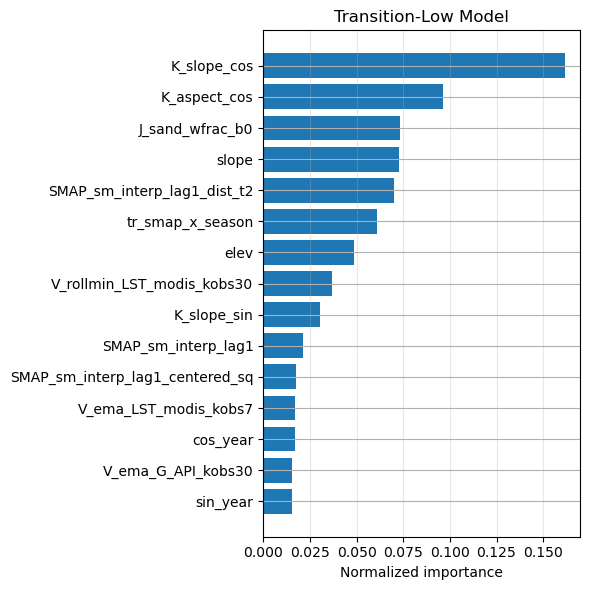


Transition-High Model - Top 15 Features
elev                               0.331305
K_aspect_cos                       0.102887
slope                              0.065805
K_slope_cos                        0.058539
V_rollmin_LST_modis_kobs30         0.047077
cos_year                           0.041501
K_slope_sin                        0.032411
sin_year                           0.028274
year_frac                          0.023097
SMAP_sm_interp_lag1_centered_sq    0.022769
tr_smap_x_season                   0.019755
SMAP_sm_interp_lag1_pos_raw        0.013267
SMAP_ampm_diff_interp              0.012374
SMAP_sm_interp_lag1_dist_t1        0.011622
API_x_year                         0.011316


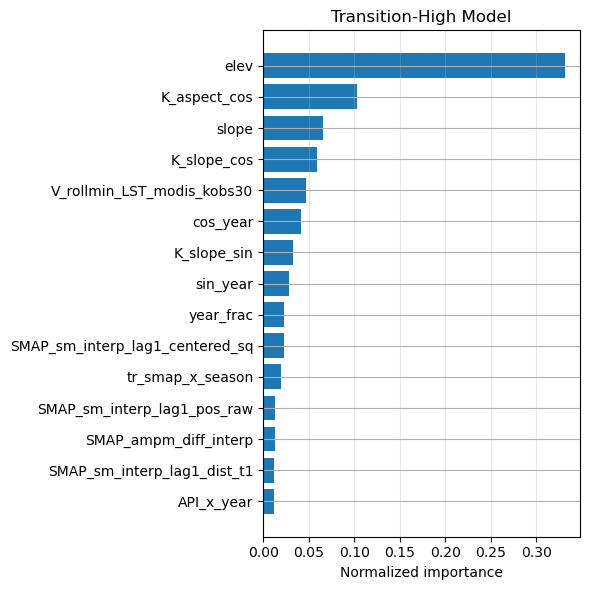

In [23]:
plot_top_features(trans_low_model, FEATURE_COLS_TRANSITION_FINAL, "Transition-Low Model")
plot_top_features(trans_high_model, FEATURE_COLS_TRANSITION_FINAL, "Transition-High Model")

In [24]:
metrics_dashboard(
    y_val_dry,
    pred_dry_val,
    name="DRY EXPERT ON DRY VAL ROWS",
    return_dict=False
)

metrics_dashboard(
    y_val_trans_low,
    pred_trans_low_val,
    name="TRANSITION-LOW EXPERT ON TRANSITION-LOW VAL ROWS",
    return_dict=False
)

metrics_dashboard(
    y_val_trans_high,
    pred_trans_high_val,
    name="TRANSITION-HIGH EXPERT ON TRANSITION-HIGH VAL ROWS",
    return_dict=False
)

metrics_dashboard(
    y_val_wet,
    pred_wet_val,
    name="WET EXPERT ON WET VAL ROWS",
    return_dict=False
)

In [25]:
y_val_transition_combined = pd.concat(
    [y_val_trans_low, y_val_trans_high]
).sort_index()

pred_transition_val_combined = pd.concat(
    [
        pd.Series(pred_trans_low_val, index=y_val_trans_low.index),
        pd.Series(pred_trans_high_val, index=y_val_trans_high.index),
    ]
).sort_index()

metrics_dashboard(
    y_val_transition_combined,
    pred_transition_val_combined,
    name="COMBINED TRANSITION (LOW + HIGH)",
    return_dict=False
)

In [26]:
metrics_dashboard(
    y_test_dry,
    pred_dry_test,
    name="DRY EXPERT ON DRY TEST ROWS",
    return_dict=False
)

metrics_dashboard(
    y_test_trans_low,
    pred_trans_low_test,
    name="TRANSITION-LOW EXPERT ON TRANSITION-LOW TEST ROWS",
    return_dict=False
)

metrics_dashboard(
    y_test_trans_high,
    pred_trans_high_test,
    name="TRANSITION-HIGH EXPERT ON TRANSITION-HIGH TEST ROWS",
    return_dict=False
)

metrics_dashboard(
    y_test_wet,
    pred_wet_test,
    name="WET EXPERT ON WET TEST ROWS",
    return_dict=False
)

In [27]:
y_test_transition_combined = pd.concat(
    [y_test_trans_low, y_test_trans_high]
).sort_index()

pred_transition_test_combined = pd.concat(
    [
        pd.Series(pred_trans_low_test, index=y_test_trans_low.index),
        pd.Series(pred_trans_high_test, index=y_test_trans_high.index),
    ]
).sort_index()

metrics_dashboard(
    y_test_transition_combined,
    pred_transition_test_combined,
    name="COMBINED TRANSITION (LOW + HIGH)",
    return_dict=False
)

In [28]:
neat_print(
    get_metrics_dict(y_val_dry, pred_dry_val, prefix=""),
    "DRY REGIME (VAL)"
)

neat_print(
    get_metrics_dict(y_val_trans_low, pred_trans_low_val, prefix=""),
    "TRANSITION-LOW REGIME (VAL)"
)

neat_print(
    get_metrics_dict(y_val_trans_high, pred_trans_high_val, prefix=""),
    "TRANSITION-HIGH REGIME (VAL)"
)

neat_print(
    get_metrics_dict(y_val_transition_combined, pred_transition_val_combined, prefix=""),
    "TRANSITION COMBINED (VAL)"
)

neat_print(
    get_metrics_dict(y_val_wet, pred_wet_val, prefix=""),
    "WET REGIME (VAL)"
)

neat_print(
    get_metrics_dict(y_test_dry, pred_dry_test, prefix=""),
    "DRY REGIME (TEST)"
)

neat_print(
    get_metrics_dict(y_test_trans_low, pred_trans_low_test, prefix=""),
    "TRANSITION-LOW REGIME (TEST)"
)

neat_print(
    get_metrics_dict(y_test_trans_high, pred_trans_high_test, prefix=""),
    "TRANSITION-HIGH REGIME (TEST)"
)

neat_print(
    get_metrics_dict(y_test_transition_combined, pred_transition_test_combined, prefix=""),
    "TRANSITION COMBINED (TEST)"
)

neat_print(
    get_metrics_dict(y_test_wet, pred_wet_test, prefix=""),
    "WET REGIME (TEST)"
)


DRY REGIME (VAL)
Metric                          Value
------------------------------------------
n                                 988
r2                            0.55101
mae                           0.02292
rmse                          0.03079
ubrmse                        0.03064
bias                          0.00298
med_ae                        0.01662
p90_ae                        0.04802
q05_err                      -0.04395
q50_err                       0.00240
q95_err                       0.05564

TRANSITION-LOW REGIME (VAL)
Metric                          Value
------------------------------------------
n                                 360
r2                            0.19788
mae                           0.01159
rmse                          0.01440
ubrmse                        0.01382
bias                          0.00403
med_ae                        0.00983
p90_ae                        0.02391
q05_err                      -0.01776
q50_err                       0

## Residuals

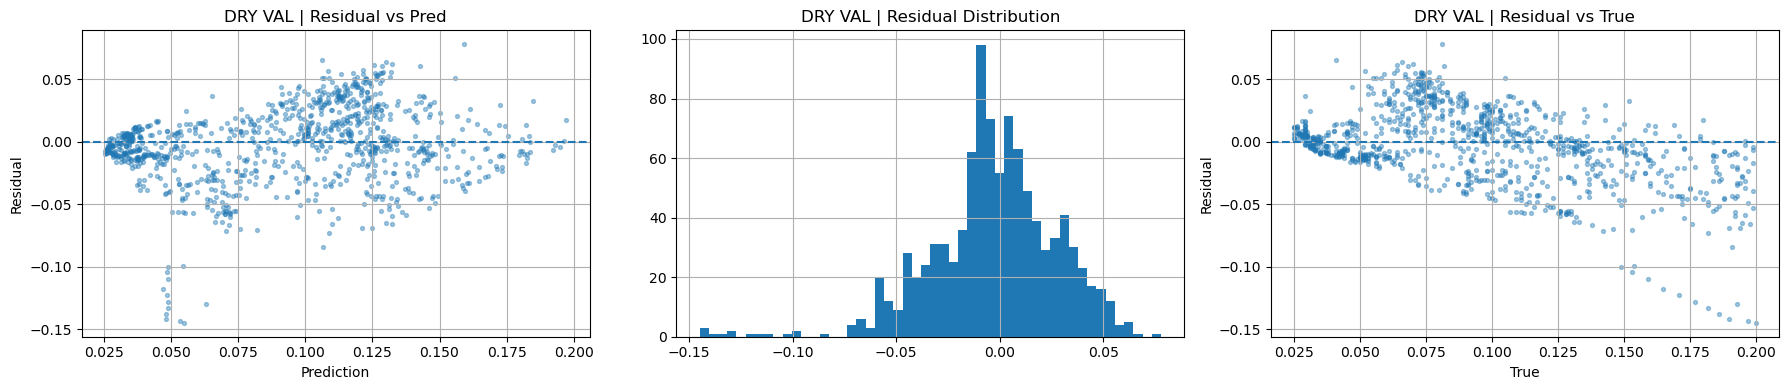

DRY VAL mean residual (bias): -0.002976
DRY VAL median residual: -0.002398


In [29]:
plot_residuals(y_val_dry.to_numpy(), pred_dry_val, "DRY VAL")

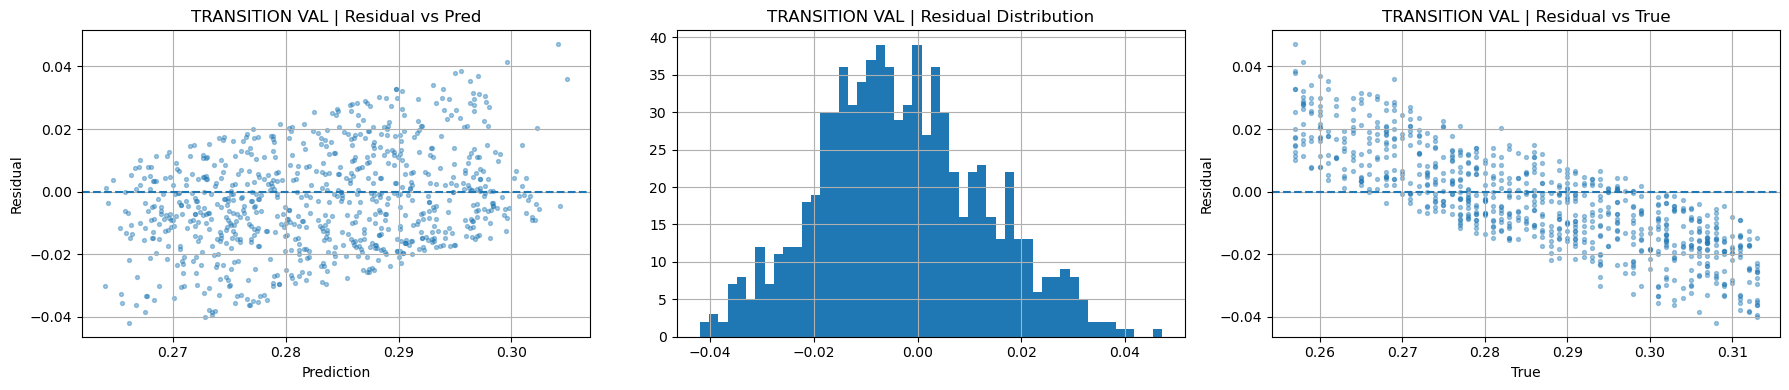

TRANSITION VAL mean residual (bias): -0.002962
TRANSITION VAL median residual: -0.004010


In [ ]:
plot_residuals(y_val_trans_high.to_numpy(), pred_trans_high_val, "TRANSITION VAL (HIGH)")

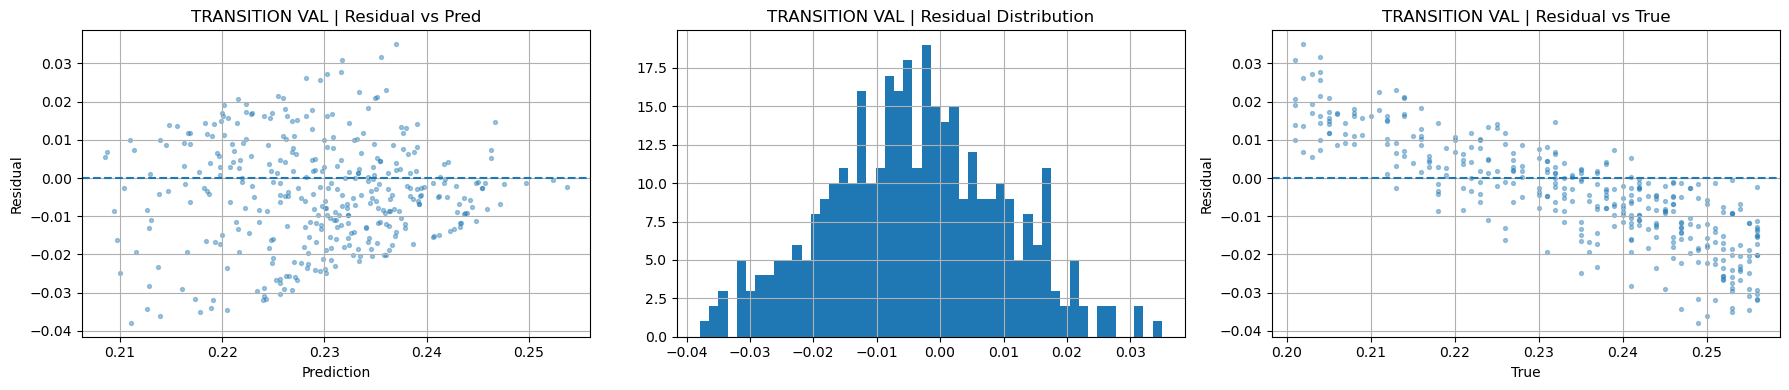

TRANSITION VAL mean residual (bias): -0.004035
TRANSITION VAL median residual: -0.004335


In [ ]:
plot_residuals(y_val_trans_low.to_numpy(), pred_trans_low_val, "TRANSITION VAL (LOW)")

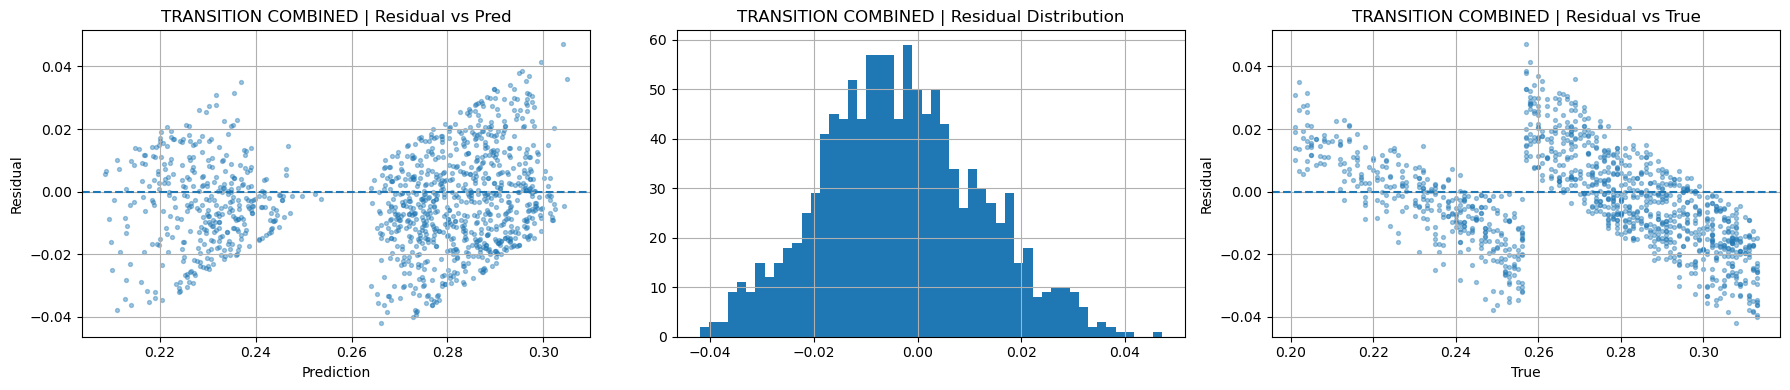

TRANSITION COMBINED mean residual (bias): -0.003296
TRANSITION COMBINED median residual: -0.004190


In [42]:
plot_residuals(y_val_transition_combined.to_numpy(), pred_transition_val_combined, "TRANSITION COMBINED")

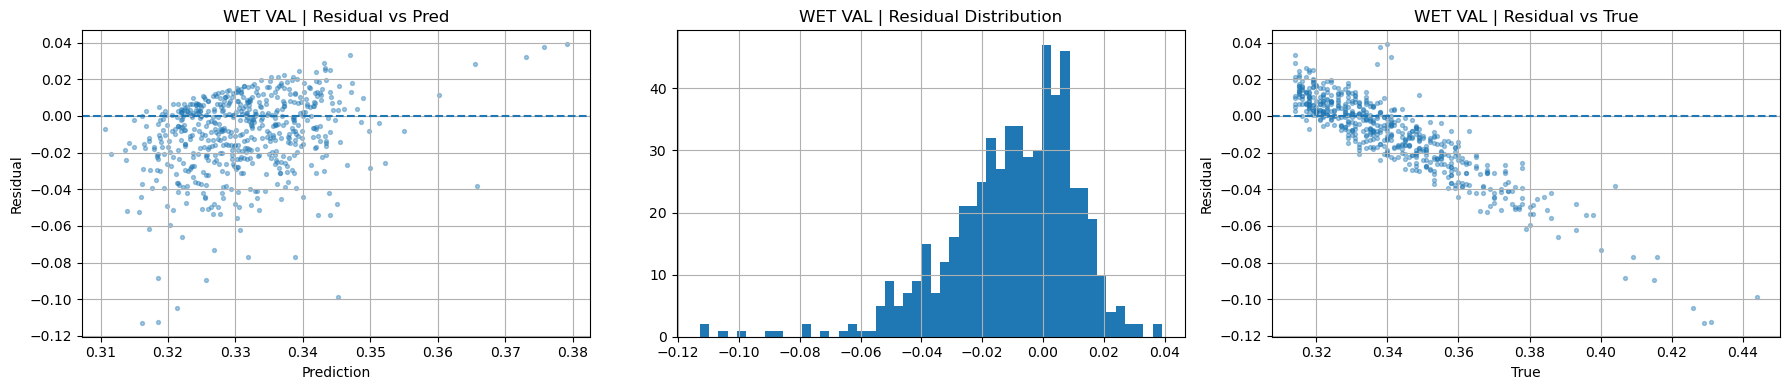

WET VAL mean residual (bias): -0.010054
WET VAL median residual: -0.006972


In [32]:
plot_residuals(y_val_wet.to_numpy(), pred_wet_val, "WET VAL")

In [33]:
residual_by_bins(y_val_transition_combined.to_numpy(), pred_transition_val_combined, "TRANSITION VAL")


TRANSITION VAL | Residual by true-value bins
bin 0: y in [0.201, 0.212] | mean res = 0.01607 | n=50
bin 1: y in [0.212, 0.223] | mean res = 0.00582 | n=52
bin 2: y in [0.223, 0.235] | mean res = 0.00024 | n=62
bin 3: y in [0.235, 0.246] | mean res = -0.00812 | n=89
bin 4: y in [0.246, 0.257] | mean res = -0.01730 | n=107
bin 5: y in [0.257, 0.268] | mean res = 0.01765 | n=136
bin 6: y in [0.268, 0.279] | mean res = 0.00555 | n=165
bin 7: y in [0.279, 0.291] | mean res = -0.00328 | n=161
bin 8: y in [0.291, 0.302] | mean res = -0.01078 | n=151
bin 9: y in [0.302, 0.313] | mean res = -0.01835 | n=169


In [34]:
residual_by_bins(y_val_wet.to_numpy(), pred_wet_val, "WET VAL")


WET VAL | Residual by true-value bins
bin 0: y in [0.314, 0.327] | mean res = 0.00900 | n=157
bin 1: y in [0.327, 0.340] | mean res = -0.00179 | n=151
bin 2: y in [0.340, 0.353] | mean res = -0.01298 | n=122
bin 3: y in [0.353, 0.366] | mean res = -0.02521 | n=79
bin 4: y in [0.366, 0.379] | mean res = -0.03993 | n=41
bin 5: y in [0.379, 0.392] | mean res = -0.05257 | n=12
bin 6: y in [0.392, 0.405] | mean res = -0.05488 | n=6
bin 7: y in [0.405, 0.418] | mean res = -0.08303 | n=4
bin 8: y in [0.418, 0.431] | mean res = -0.10877 | n=2
bin 9: y in [0.431, 0.444] | mean res = -0.11254 | n=1


> # Important
> The transition model captures global structure well, with no easily correctable bias via residual modeling

---

_Jakob Balkovec_